In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



### Identifying CSV files with more than 51 rows across all user folders

I'll now iterate through each 'User' folder (from User1 to User9) in the `dyfav` directory. For each CSV file found, I'll load it into a Pandas DataFrame and record its `user_id`, `file_index`, and `row_count` if the number of rows exceeds 51.

In [3]:
base_dir = '/home/satwik-biswas/Downloads/dyfav'

files_with_different_row_counts = []

# Loop through User1 to User9 folders
for i in range(1, 10):
    user_folder_name = f'User{i}'
    user_folder_path = os.path.join(base_dir, user_folder_name)

    if os.path.exists(user_folder_path):
        # Get all csv files in the user's folder
        all_csv_files_in_user_folder = [f for f in os.listdir(user_folder_path) if f.endswith('.csv')]

        for file_index, file_name in enumerate(all_csv_files_in_user_folder):
            file_path = os.path.join(user_folder_path, file_name)
            try:
                df_temp = pd.read_csv(file_path)
                row_count = df_temp.shape[0]

                if row_count > 51:
                    files_with_different_row_counts.append({
                        'user_id': user_folder_name,
                        'file_index': file_index, 
                        'file_name': file_name,
                        'row_count': row_count
                    })
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

print(f"Found {len(files_with_different_row_counts)} files with more than 51 rows.")
if files_with_different_row_counts:
    display(pd.DataFrame(files_with_different_row_counts))
else:
    print("No files found with more than 51 rows.")

Found 10 files with more than 51 rows.


,user_id,file_index,file_name,row_count
0,User1,42,291982963_alphabet_u_right.csv,101
1,User1,64,291982937_alphabet_s_right.csv,101
2,User1,68,291982821_alphabet_i_right.csv,101
3,User1,77,291983028_alphabet_y_right.csv,101
4,User7,38,291996584_alphabet_e_right.csv,101
5,User7,66,291996562_alphabet_b_right.csv,101
6,User7,93,291996590_alphabet_e_right.csv,101
7,User8,81,291981192_alphabet_x_right.csv,101
8,User8,92,291981085_alphabet_k_right.csv,101
9,User8,110,291981193_alphabet_x_right.csv,101


### General Duplicate Check for Files with More Than 51 Rows

Since the specific duplication pattern wasn't found, we'll now perform a general check for *any* duplicate rows within each of the files that have more than 51 rows. This will identify if there are any identical rows appearing more than once in the entire dataset of these files.

In [4]:
general_duplicate_results = []

for index, row in pd.DataFrame(files_with_different_row_counts).iterrows():
    user_folder_name = row['user_id']
    file_name = row['file_name']
    file_path = os.path.join(base_dir, user_folder_name, file_name)

    try:
        df_current = pd.read_csv(file_path)

        # Check for any duplicate rows in the entire DataFrame
        has_any_duplicates = df_current.duplicated().any()
        total_duplicates = df_current.duplicated().sum()

        general_duplicate_results.append({
            'user_id': user_folder_name,
            'file_name': file_name,
            'row_count': df_current.shape[0],
            'has_any_duplicates': has_any_duplicates,
            'total_duplicate_rows': total_duplicates
        })
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

if general_duplicate_results:
    print("General duplicate check complete for files with more than 51 rows:")
    display(pd.DataFrame(general_duplicate_results))
else:
    print("No files with more than 51 rows were found.")

General duplicate check complete for files with more than 51 rows:


,user_id,file_name,row_count,has_any_duplicates,total_duplicate_rows
0,User1,291982963_alphabet_u_right.csv,101,False,0
1,User1,291982937_alphabet_s_right.csv,101,False,0
2,User1,291982821_alphabet_i_right.csv,101,False,0
3,User1,291983028_alphabet_y_right.csv,101,False,0
4,User7,291996584_alphabet_e_right.csv,101,False,0
5,User7,291996562_alphabet_b_right.csv,101,False,0
6,User7,291996590_alphabet_e_right.csv,101,False,0
7,User8,291981192_alphabet_x_right.csv,101,False,0
8,User8,291981085_alphabet_k_right.csv,101,False,0
9,User8,291981193_alphabet_x_right.csv,101,False,0


### Creating a Copy of `dyfav` and Deleting Files

To ensure the integrity of your original data, I'll first create a complete copy of the `dyfav` directory. Then, from this new copied directory, I will delete the CSV files that were identified as having more than 51 rows.

In [5]:
import shutil

original_dyfav_path = '/home/satwik-biswas/Downloads/dyfav'
copied_dyfav_path = '/home/satwik-biswas/Downloads/dyfav_copy'

# Create a copy of the dyfav folder
print(f"Copying '{original_dyfav_path}' to '{copied_dyfav_path}'...")
if os.path.exists(copied_dyfav_path):
    shutil.rmtree(copied_dyfav_path)
    print("Existing copy removed.")
shutil.copytree(original_dyfav_path, copied_dyfav_path)
print("Copy complete.")


Copying '/home/satwik-biswas/Downloads/dyfav' to '/home/satwik-biswas/Downloads/dyfav_copy'...
Existing copy removed.
Copy complete.


In [6]:
deleted_files_count = 0

# Iterate through the files identified as having more than 51 rows
for index, row in pd.DataFrame(files_with_different_row_counts).iterrows():
    user_id = row['user_id']
    file_name_to_delete = row['file_name']

    # Construct the path to the file in the *copied* directory
    file_path_in_copy = os.path.join(copied_dyfav_path, user_id, file_name_to_delete)

    if os.path.exists(file_path_in_copy):
        os.remove(file_path_in_copy)
        print(f"Deleted: {file_path_in_copy}")
        deleted_files_count += 1
    else:
        print(f"File not found in copy (already deleted or path error): {file_path_in_copy}")

print(f"\nSuccessfully deleted {deleted_files_count} files from the copied 'dyfav_copy' folder.")


Deleted: /home/satwik-biswas/Downloads/dyfav_copy/User1/291982963_alphabet_u_right.csv
Deleted: /home/satwik-biswas/Downloads/dyfav_copy/User1/291982937_alphabet_s_right.csv
Deleted: /home/satwik-biswas/Downloads/dyfav_copy/User1/291982821_alphabet_i_right.csv
Deleted: /home/satwik-biswas/Downloads/dyfav_copy/User1/291983028_alphabet_y_right.csv
Deleted: /home/satwik-biswas/Downloads/dyfav_copy/User7/291996584_alphabet_e_right.csv
Deleted: /home/satwik-biswas/Downloads/dyfav_copy/User7/291996562_alphabet_b_right.csv
Deleted: /home/satwik-biswas/Downloads/dyfav_copy/User7/291996590_alphabet_e_right.csv
Deleted: /home/satwik-biswas/Downloads/dyfav_copy/User8/291981192_alphabet_x_right.csv
Deleted: /home/satwik-biswas/Downloads/dyfav_copy/User8/291981085_alphabet_k_right.csv
Deleted: /home/satwik-biswas/Downloads/dyfav_copy/User8/291981193_alphabet_x_right.csv

Successfully deleted 10 files from the copied 'dyfav_copy' folder.


### Analyzing File Distribution by Alphabet Letter in `dyfav_copy`

Now, let's look at the remaining files in the `dyfav_copy` folder and count how many files correspond to each alphabet letter for every user. This will help us understand the current distribution of data after the deletions.

In [7]:
import re

alphabet_counts = {}
copied_base_dir = '/home/satwik-biswas/Downloads/dyfav_copy/'

pd.set_option('display.max_columns', None) # Set display option to show all columns

# Loop through User1 to User9 folders in the copied directory
for i in range(1, 10):
    user_folder_name = f'User{i}'
    user_folder_path = os.path.join(copied_base_dir, user_folder_name)

    if os.path.exists(user_folder_path):
        user_letter_counts = {}

        # Get all csv files in the user's copied folder
        all_csv_files_in_user_folder = [f for f in os.listdir(user_folder_path) if f.endswith('.csv')]

        for file_name in all_csv_files_in_user_folder:
            # Extract the alphabet letter using a regular expression
            match = re.search(r'alphabet_([a-zA-Z])_right\.csv', file_name)
            if match:
                letter = match.group(1).upper() # Get the letter and convert to uppercase
                user_letter_counts[letter] = user_letter_counts.get(letter, 0) + 1

        if user_letter_counts:
            alphabet_counts[user_folder_name] = user_letter_counts

# Prepare data for DataFrame display
data_for_df = []
for user, counts in alphabet_counts.items():
    for letter, count in counts.items():
        data_for_df.append({'User': user, 'Alphabet_Letter': letter, 'File_Count': count})

if data_for_df:
    df_letter_distribution = pd.DataFrame(data_for_df)
    # Pivot the table for better readability
    df_pivot = df_letter_distribution.pivot_table(index='User', columns='Alphabet_Letter', values='File_Count', fill_value=0)
    display(df_pivot)
else:
    print("No CSV files found in the copied 'dyfav_copy' folder to analyze.")

Alphabet_Letter,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T,U,V,W,X,Y,Z
User,,,,,,,,,,,,,,,,,,,,,,,,,,
User1,5.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0,4.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0,4.0,5.0,4.0,5.0,5.0,5.0,4.0,5.0
User2,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0
User3,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0
User4,5.0,5.0,5.0,5.0,5.0,5.0,5.0,7.0,6.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
User5,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0,5.0,6.0,6.0,5.0,5.0,5.0,5.0,6.0,5.0,5.0,5.0,5.0
User6,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0,5.0,5.0
User7,5.0,4.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0,5.0,6.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0
User8,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,3.0,5.0,5.0
User9,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0


### Total Files Per User

Let's calculate the total number of files for each user by summing up the counts across all alphabet letters from the `df_pivot` table.

In [8]:
if 'df_pivot' in locals() and not df_pivot.empty:
    total_files_per_user = df_pivot.sum(axis=1).reset_index()
    total_files_per_user.columns = ['User', 'Total_Files']
    print("Total files per user:")
    display(total_files_per_user)
else:
    print("df_pivot DataFrame not found or is empty. Please ensure the previous cell was executed successfully.")

Total files per user:


,User,Total_Files
0,User1,128.0
1,User2,132.0
2,User3,132.0
3,User4,133.0
4,User5,134.0
5,User6,131.0
6,User7,130.0
7,User8,127.0
8,User9,131.0


### Identifying Unbalanced File Counts for Specific Letters

Based on the table above, it appears that a count of `5.0` is the most common for each letter per user. Let's identify the instances where the file count for a specific letter deviates from this common value.

In [9]:
unbalanced_files = []

# Assuming df_pivot is the DataFrame from the previous step
if 'df_pivot' in locals() and not df_pivot.empty:
    for user in df_pivot.index:
        for letter in df_pivot.columns:
            count = df_pivot.loc[user, letter]
            # Assuming 5.0 is the 'balanced' count
            if count != 5.0:
                unbalanced_files.append({
                    'User': user,
                    'Alphabet_Letter': letter,
                    'File_Count': count
                })

    if unbalanced_files:
        df_unbalanced = pd.DataFrame(unbalanced_files)
        print("Users with unbalanced file counts for specific letters:")
        display(df_unbalanced)
    else:
        print("All file counts appear to be balanced (all 5.0).")
else:
    print("df_pivot DataFrame not found or is empty. Please ensure the previous cell was executed successfully.")

Users with unbalanced file counts for specific letters:


,User,Alphabet_Letter,File_Count
0,User1,G,6.0
1,User1,I,4.0
2,User1,R,6.0
3,User1,S,4.0
4,User1,U,4.0
5,User1,Y,4.0
6,User2,H,6.0
7,User2,Y,6.0
8,User3,Q,6.0
9,User3,Z,6.0


SO NO NEED TO DELETE FILES FURTHER. USER IMBALACE IS MAXIMUM +3% AND MINIMUM -2.3% WHICH IS WAY UNDER THE ACCEPTED LIMIT. HOWEVER FOR EACH INDIVUDUAL LETTER THE CLASS IMBALANCE VARIES FROM 40% TO -40% WHICH IS STILL FINE SINCE TREE MODELS HANDLE IT VERY EASILY


**ZEROING**

### Implementing Zeroing for EMG Sensor Data

As requested, the 'zeroing' process will now specifically target the `emg1` through `emg8` sensor features. For these features, the mean of the first 5 data points will be subtracted from all subsequent data points to remove baseline bias. Other sensor features will be kept as is.

In [10]:
import os

def zero_emg_data(df, emg_cols, num_baseline_rows=3):
    """Zeroes out specified EMG sensor data by subtracting the mean of the first `num_baseline_rows`.
    Non-EMG columns are returned unchanged.

    Args:
        df (pd.DataFrame): The input DataFrame containing sensor data.
        emg_cols (list): A list of column names that are EMG sensor features to be zeroed.
        num_baseline_rows (int): The number of initial rows to use for calculating the baseline mean.

    Returns:
        pd.DataFrame: The DataFrame with specified EMG sensor data zeroed, and other columns untouched.
    """
    df_zeroed = df.copy()
    for col in emg_cols:
        if col in df.columns:
            # Calculate the baseline mean from the first 'num_baseline_rows'
            baseline_mean = df[col].iloc[:num_baseline_rows].mean()
            # Subtract the baseline mean from the entire EMG column
            df_zeroed[col] = df[col] - baseline_mean
    return df_zeroed

# Define all 17 sensor feature columns for column assignment
sensor_features = [
    'emg1', 'emg2', 'emg3', 'emg4', 'emg5', 'emg6', 'emg7', 'emg8',
    'accel_x', 'accel_y', 'accel_z',
    'gyro_x', 'gyro_y', 'gyro_z',
    'roll', 'pitch', 'yaw'
]

# Define only the EMG columns that need to be zeroed
emg_cols_to_zero = [
    'emg1', 'emg2', 'emg3', 'emg4', 'emg5', 'emg6', 'emg7', 'emg8'
]

original_dyfav_path = '/home/satwik-biswas/Downloads/dyfav_copy/'
zeroed_dyfav_path = '/home/satwik-biswas/Downloads/dyfav_zeroed/'# Path for saving zeroed files

# Create the new base directory for zeroed files if it doesn't exist
os.makedirs(zeroed_dyfav_path, exist_ok=True)

print(f"Starting EMG zeroing process from '{original_dyfav_path}' to '{zeroed_dyfav_path}'...")

processed_count = 0
# Iterate through User1 to User9 folders in the original directory
for i in range(1, 10):
    user_folder_name = f'User{i}'
    user_original_path = os.path.join(original_dyfav_path, user_folder_name)
    user_zeroed_path = os.path.join(zeroed_dyfav_path, user_folder_name)

    # Create user subdirectory in dyfav_zeroed
    os.makedirs(user_zeroed_path, exist_ok=True)

    if os.path.exists(user_original_path):
        all_csv_files_in_user_folder = [f for f in os.listdir(user_original_path) if f.endswith('.csv')]
        print(f"Processing {len(all_csv_files_in_user_folder)} files in {user_folder_name}...")

        for file_name in all_csv_files_in_user_folder:
            file_path_original = os.path.join(user_original_path, file_name)
            file_path_zeroed = os.path.join(user_zeroed_path, file_name)

            try:
                df = pd.read_csv(file_path_original, header=None)

                num_cols = df.shape[1]
                expected_sensor_cols = len(sensor_features)

                # Assign columns names based on the number of columns
                if num_cols == expected_sensor_cols: # Case: 17 columns (sensor data only)
                    df.columns = sensor_features
                elif num_cols == expected_sensor_cols + 1: # Case: 18 columns (sensor data + label)
                    df.columns = sensor_features + ['label']
                else:
                    print(f"Warning: Skipping {file_name} in {user_folder_name}. Unexpected number of columns ({num_cols}). Expected 17 or 18.")
                    continue

                # Apply zeroing ONLY to the specified EMG features
                df_zeroed_data = zero_emg_data(df, emg_cols_to_zero)

                # Save the zeroed DataFrame to the new directory, preserving original column order
                df_zeroed_data.to_csv(file_path_zeroed, index=False, header=False)
                processed_count += 1

            except Exception as e:
                print(f"Error processing {file_name} in {user_folder_name}: {e}")
    else:
        print(f"User folder not found: {user_original_path}")

print(f"\nEMG Zeroing complete. Successfully processed and saved {processed_count} files to '{zeroed_dyfav_path}' folder.")

Starting EMG zeroing process from '/home/satwik-biswas/Downloads/dyfav_copy/' to '/home/satwik-biswas/Downloads/dyfav_zeroed/'...
Processing 128 files in User1...


Processing 132 files in User2...
Processing 132 files in User3...
Processing 133 files in User4...
Processing 134 files in User5...
Processing 131 files in User6...
Processing 130 files in User7...
Processing 127 files in User8...
Processing 131 files in User9...

EMG Zeroing complete. Successfully processed and saved 1178 files to '/home/satwik-biswas/Downloads/dyfav_zeroed/' folder.


### Feature Engineering: Global and Segmented Statistics

This section will perform feature engineering on the CSV files in `dyfav_copy`. For each file, it will calculate:

1.  **Global Features**: `min`, `max`, `mean`, `std_dev`, and `tot_eng` for each of the 17 sensor features over the entire 51 rows.
2.  **Segmented Features**: The same 5 statistics for each of the 17 sensor features, but divided into 5 segments (rows 1-10, 11-20, 21-30, 31-40, 41-51).

Each original CSV file will result in a new CSV file in a new directory (`dybaf_1`) containing a single row with `user_id`, `file_name`, `label`, and all 510 (85 global + 425 segmented) engineered features. A master CSV combining all these features across all files will also be generated.

In [11]:
import re
import shutil

def calculate_features(df_segment, feature_cols, prefix=""):
    """Calculates min, max, mean, std_dev, and total energy for given columns in a DataFrame segment."""
    features = {}
    for col in feature_cols:
        col_prefix = f"{prefix}{col}_" if prefix else f"{col}_"
        features[f"{col_prefix}min"] = df_segment[col].min()
        features[f"{col_prefix}max"] = df_segment[col].max()
        features[f"{col_prefix}mean"] = df_segment[col].mean()

        std_val = df_segment[col].std()
        features[f"{col_prefix}std_dev"] = std_val if not pd.isna(std_val) else 0.0 # Replace NaN std with 0, especially for single-value segments

        features[f"{col_prefix}tot_eng"] = (df_segment[col]**2).sum()
    return features

# Define paths
dyfav_copy_base_dir = '/home/satwik-biswas/Downloads/dyfav_zeroed/'
dybaf_1_base_dir = '/home/satwik-biswas/Downloads/dyfav_1'

# Create the new base directory for engineered features if it doesn't exist
os.makedirs(dybaf_1_base_dir, exist_ok=True)

# Define the 17 sensor feature columns based on notebook context
sensor_features = [
    'emg1', 'emg2', 'emg3', 'emg4', 'emg5', 'emg6', 'emg7', 'emg8',
    'accel_x', 'accel_y', 'accel_z',
    'gyro_x', 'gyro_y', 'gyro_z',
    'roll', 'pitch', 'yaw'
]

all_processed_files_data = [] # To collect all feature sets for a final master DataFrame

print(f"Starting feature engineering from '{dyfav_copy_base_dir}' to '{dybaf_1_base_dir}'...")

# Iterate through User1 to User9 folders in the copied directory
for i in range(1, 10):
    user_folder_name = f'User{i}'
    user_dyfav_copy_path = os.path.join(dyfav_copy_base_dir, user_folder_name)
    user_dybaf_1_path = os.path.join(dybaf_1_base_dir, user_folder_name)

    # Create user subdirectory in dybaf_1
    os.makedirs(user_dybaf_1_path, exist_ok=True)

    if os.path.exists(user_dyfav_copy_path):
        all_csv_files_in_user_folder = [f for f in os.listdir(user_dyfav_copy_path) if f.endswith('.csv')]
        all_csv_files_in_user_folder.sort(key=lambda var: [int(x) if x.isdigit() else x for x in re.split(r'(\d+)', var)])
        print(f"Processing {len(all_csv_files_in_user_folder)} files in {user_folder_name}...")

        for file_name in all_csv_files_in_user_folder:
            file_path_in_copy = os.path.join(user_dyfav_copy_path, file_name)

            try:
                # Read CSV without a header to ensure integer column names initially
                df = pd.read_csv(file_path_in_copy, header=None)

                num_cols = df.shape[1]
                expected_sensor_cols = len(sensor_features)

                extracted_label = None
                df_sensor = pd.DataFrame() # Initialize df_sensor

                # Process 17-column files (sensor features only) or 18-column files (sensor features + label)
                if num_cols == expected_sensor_cols: # Case: 17 columns (sensor data only)
                    df.columns = sensor_features # Assign sensor feature names
                    df_sensor = df # All columns are sensor features
                elif num_cols == expected_sensor_cols + 1: # Case: 18 columns (sensor data + label)
                    # Assign sensor names and a temporary name for the label column
                    temp_cols = sensor_features + ['temp_label_col']
                    df.columns = temp_cols
                    extracted_label = df['temp_label_col'].iloc[0] # Extract label
                    df_sensor = df[sensor_features] # Select only sensor features for df_sensor
                else:
                    print(f"Warning: Skipping {file_name} in {user_folder_name}. Unexpected number of columns ({num_cols}). Expected 17 or 18.")
                    continue

                # Ensure the DataFrame has 50 or 51 rows (check on df_sensor)
                if df_sensor.shape[0] not in [50, 51]:
                    print(f"Warning: Skipping {file_name} in {user_folder_name}. Expected 50 or 51 rows, but found {df_sensor.shape[0]}.")
                    continue

                # If label is still None (i.e., not extracted from a column), try to extract from filename
                if extracted_label is None:
                    match = re.search(r'alphabet_([a-zA-Z])_right\.csv', file_name)
                    if match:
                        extracted_label = match.group(1).upper()
                    else:
                        print(f"Warning: Skipping {file_name} in {user_folder_name}. Label could not be extracted from column or filename.")
                        continue

                label = extracted_label # Assign to the 'label' variable used later

                # --- Calculate Global Features ---
                global_features = calculate_features(df_sensor, sensor_features, prefix="global_")

                # --- Calculate Segmented Features ---
                segmented_features = {}
                segment_definitions = {
                    "segment1": (0, 10),  # rows 1-10 (0-indexed: 0-9)
                    "segment2": (10, 20), # rows 11-20 (0-indexed: 10-19)
                    "segment3": (20, 30), # rows 21-30 (0-indexed: 20-29)
                    "segment4": (30, 40), # rows 31-40 (0-indexed: 30-39)
                    "segment5": (40, 51)  # rows 41-51 (0-indexed: 40-50). Handles 50 rows by taking df_sensor.iloc[40:50]
                }

                for seg_name, (start_row, end_row) in segment_definitions.items():
                    df_segment = df_sensor.iloc[start_row:end_row]
                    seg_features = calculate_features(df_segment, sensor_features, prefix=f"{seg_name}_")
                    segmented_features.update(seg_features)

                # Combine all features, user_id, file_name, and label
                all_features_for_file = {
                    'user_id': user_folder_name,
                    'file_name': file_name,
                    'label': label,
                    **global_features,
                    **segmented_features
                }

                all_processed_files_data.append(all_features_for_file)

                # Save individual feature file (single row CSV per original file)
                output_file_name = file_name.replace('.csv', '_features.csv') # Append _features to distinguish
                output_file_path = os.path.join(user_dybaf_1_path, output_file_name)

                pd.DataFrame([all_features_for_file]).to_csv(output_file_path, index=False)

            except Exception as e:
                print(f"Error processing {file_name} in {user_folder_name}: {e}")
    else:
        print(f"User folder not found: {user_dyfav_copy_path}")

print("\nFeature engineering complete. Individual feature files saved to 'dybaf_3' folder.")

# Combine all features into a single master DataFrame and save it
if all_processed_files_data:
    master_features_df = pd.DataFrame(all_processed_files_data)
    master_output_path = os.path.join(dybaf_1_base_dir, 'all_users_combined_features_2.csv')
    master_features_df.to_csv(master_output_path, index=False)
    print(f"All features combined into a master CSV: {master_output_path}")
    print(f"Total features generated per file (excluding metadata): {len(master_features_df.columns) - 3}")
    display(master_features_df.head())
else:
    print("No files were processed for feature engineering.")




Starting feature engineering from '/home/satwik-biswas/Downloads/dyfav_zeroed/' to '/home/satwik-biswas/Downloads/dyfav_1'...
Processing 128 files in User1...
Processing 132 files in User2...
Processing 132 files in User3...
Processing 133 files in User4...
Processing 134 files in User5...
Processing 131 files in User6...
Processing 130 files in User7...
Processing 127 files in User8...
Processing 131 files in User9...

Feature engineering complete. Individual feature files saved to 'dybaf_3' folder.
All features combined into a master CSV: /home/satwik-biswas/Downloads/dyfav_1/all_users_combined_features_2.csv
Total features generated per file (excluding metadata): 510


,user_id,file_name,label,global_emg1_min,global_emg1_max,global_emg1_mean,global_emg1_std_dev,global_emg1_tot_eng,global_emg2_min,global_emg2_max,global_emg2_mean,global_emg2_std_dev,global_emg2_tot_eng,global_emg3_min,global_emg3_max,global_emg3_mean,global_emg3_std_dev,global_emg3_tot_eng,global_emg4_min,global_emg4_max,global_emg4_mean,global_emg4_std_dev,global_emg4_tot_eng,global_emg5_min,global_emg5_max,global_emg5_mean,global_emg5_std_dev,global_emg5_tot_eng,global_emg6_min,global_emg6_max,global_emg6_mean,global_emg6_std_dev,global_emg6_tot_eng,global_emg7_min,global_emg7_max,global_emg7_mean,global_emg7_std_dev,global_emg7_tot_eng,global_emg8_min,global_emg8_max,global_emg8_mean,global_emg8_std_dev,global_emg8_tot_eng,global_accel_x_min,global_accel_x_max,global_accel_x_mean,global_accel_x_std_dev,global_accel_x_tot_eng,global_accel_y_min,global_accel_y_max,global_accel_y_mean,global_accel_y_std_dev,global_accel_y_tot_eng,global_accel_z_min,global_accel_z_max,global_accel_z_mean,global_accel_z_std_dev,global_accel_z_tot_eng,global_gyro_x_min,global_gyro_x_max,global_gyro_x_mean,global_gyro_x_std_dev,global_gyro_x_tot_eng,global_gyro_y_min,global_gyro_y_max,global_gyro_y_mean,global_gyro_y_std_dev,global_gyro_y_tot_eng,global_gyro_z_min,global_gyro_z_max,global_gyro_z_mean,global_gyro_z_std_dev,global_gyro_z_tot_eng,global_roll_min,global_roll_max,global_roll_mean,global_roll_std_dev,global_roll_tot_eng,global_pitch_min,global_pitch_max,global_pitch_mean,global_pitch_std_dev,global_pitch_tot_eng,global_yaw_min,global_yaw_max,global_yaw_mean,global_yaw_std_dev,global_yaw_tot_eng,segment1_emg1_min,segment1_emg1_max,segment1_emg1_mean,segment1_emg1_std_dev,segment1_emg1_tot_eng,segment1_emg2_min,segment1_emg2_max,segment1_emg2_mean,segment1_emg2_std_dev,segment1_emg2_tot_eng,segment1_emg3_min,segment1_emg3_max,segment1_emg3_mean,segment1_emg3_std_dev,segment1_emg3_tot_eng,segment1_emg4_min,segment1_emg4_max,segment1_emg4_mean,segment1_emg4_std_dev,segment1_emg4_tot_eng,segment1_emg5_min,segment1_emg5_max,segment1_emg5_mean,segment1_emg5_std_dev,segment1_emg5_tot_eng,segment1_emg6_min,segment1_emg6_max,segment1_emg6_mean,segment1_emg6_std_dev,segment1_emg6_tot_eng,segment1_emg7_min,segment1_emg7_max,segment1_emg7_mean,segment1_emg7_std_dev,segment1_emg7_tot_eng,segment1_emg8_min,segment1_emg8_max,segment1_emg8_mean,segment1_emg8_std_dev,segment1_emg8_tot_eng,segment1_accel_x_min,segment1_accel_x_max,segment1_accel_x_mean,segment1_accel_x_std_dev,segment1_accel_x_tot_eng,segment1_accel_y_min,segment1_accel_y_max,segment1_accel_y_mean,segment1_accel_y_std_dev,segment1_accel_y_tot_eng,segment1_accel_z_min,segment1_accel_z_max,segment1_accel_z_mean,segment1_accel_z_std_dev,segment1_accel_z_tot_eng,segment1_gyro_x_min,segment1_gyro_x_max,segment1_gyro_x_mean,segment1_gyro_x_std_dev,segment1_gyro_x_tot_eng,segment1_gyro_y_min,segment1_gyro_y_max,segment1_gyro_y_mean,segment1_gyro_y_std_dev,segment1_gyro_y_tot_eng,segment1_gyro_z_min,segment1_gyro_z_max,segment1_gyro_z_mean,segment1_gyro_z_std_dev,segment1_gyro_z_tot_eng,segment1_roll_min,segment1_roll_max,segment1_roll_mean,segment1_roll_std_dev,segment1_roll_tot_eng,segment1_pitch_min,segment1_pitch_max,segment1_pitch_mean,segment1_pitch_std_dev,segment1_pitch_tot_eng,segment1_yaw_min,segment1_yaw_max,segment1_yaw_mean,segment1_yaw_std_dev,segment1_yaw_tot_eng,segment2_emg1_min,segment2_emg1_max,segment2_emg1_mean,segment2_emg1_std_dev,segment2_emg1_tot_eng,segment2_emg2_min,segment2_emg2_max,segment2_emg2_mean,segment2_emg2_std_dev,segment2_emg2_tot_eng,segment2_emg3_min,segment2_emg3_max,segment2_emg3_mean,segment2_emg3_std_dev,segment2_emg3_tot_eng,segment2_emg4_min,segment2_emg4_max,segment2_emg4_mean,segment2_emg4_std_dev,segment2_emg4_tot_eng,segment2_emg5_min,segment2_emg5_max,segment2_emg5_mean,segment2_emg5_std_dev,segment2_emg5_tot_eng,segment2_emg6_min,segment2_emg6_max,segment2_emg6_mean,segment2_emg6_std_dev,segment2_emg6_tot_eng,segment2_emg7_min,segment2_emg7_max

In [3]:
df1=pd.read_csv(r"..\datasets\American_Sign_Language_Fingerspelling_dataset_copy_engineered\all_users_combined_features_2.csv")
df1.head()

,user_id,file_name,label,global_emg1_min,global_emg1_max,global_emg1_mean,global_emg1_std_dev,global_emg1_tot_eng,global_emg2_min,global_emg2_max,...,segment5_pitch_min,segment5_pitch_max,segment5_pitch_mean,segment5_pitch_std_dev,segment5_pitch_tot_eng,segment5_yaw_min,segment5_yaw_max,segment5_yaw_mean,segment5_yaw_std_dev,segment5_yaw_tot_eng
0,User1,291982754_alphabet_a_right.csv,A,-63.333333,112.666667,1.098039,30.300663,45968.000000,-57.666667,54.333333,...,25,25,25.0,0.0,6875,25,25,25.000000,0.000000,6875
1,User1,291982756_alphabet_a_right.csv,A,-51.000000,78.000000,-5.745098,23.833458,30085.000000,-31.000000,26.000000,...,23,23,23.0,0.0,5819,27,27,27.000000,0.000000,8019
2,User1,291982757_alphabet_a_right.csv,A,-86.333333,44.666667,-2.372549,24.356486,29949.000000,-17.000000,41.000000,...,26,26,26.0,0.0,7436,27,28,27.636364,0.504525,8404
3,User1,291982758_alphabet_a_right.csv,A,-39.333333,128.666667,25.725490,31.411725,83086.666667,-32.666667,66.333333,...,26,26,26.0,0.0,7436,32,32,32.000000,0.000000,11264
4,User1,291982760_alphabet_a_right.csv,A,-34.000000,56.000000,3.784314,21.618801,24099.000000,-43.666667,66.333333,...,26,26,26.0,0.0,7436,33,33,33.000000,0.000000,11979


In [4]:
X = df1.drop(columns=['file_name', 'user_id', 'label'])
y = df1["label"]


from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 2/5 ≈ 40%
    stratify=y,
    random_state=42
)

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    random_state=42,
    n_estimators=1000,
    criterion="entropy",
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="log2",
    bootstrap=False,
    n_jobs=-1
)

rf.fit(X_train, y_train)

preds = rf.predict(X_test)

acc = accuracy_score(y_test, preds)

print(acc)

0.8771186440677966


In [7]:
print("accuracy",acc)
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(preds)
))

accuracy 0.8771186440677966
              precision    recall  f1-score   support

           A       1.00      0.89      0.94         9
           B       0.89      0.89      0.89         9
           C       0.90      1.00      0.95         9
           D       1.00      1.00      1.00         9
           E       0.89      0.89      0.89         9
           F       0.78      0.78      0.78         9
           G       0.82      1.00      0.90         9
           H       1.00      1.00      1.00        10
           I       0.75      1.00      0.86         9
           J       1.00      1.00      1.00         9
           K       1.00      1.00      1.00         9
           L       1.00      0.89      0.94         9
           M       0.78      0.78      0.78         9
           N       0.82      1.00      0.90         9
           O       0.89      0.89      0.89         9
           P       1.00      0.67      0.80         9
           Q       1.00      1.00      1.00        10

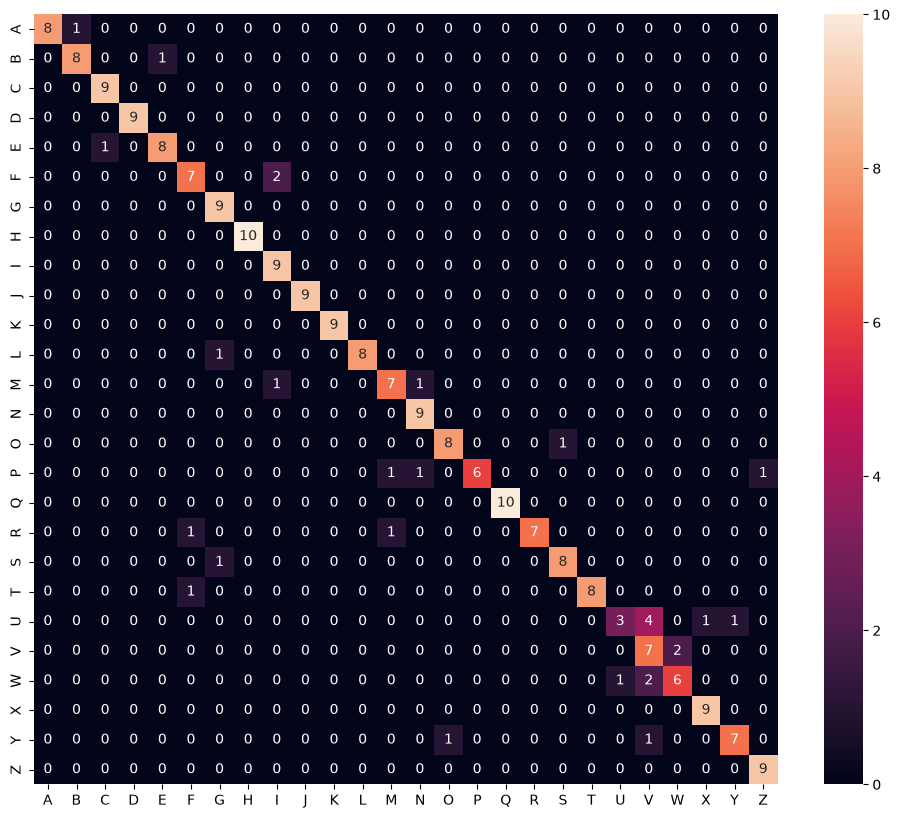

In [8]:
cm = confusion_matrix(y_test, preds)

cm_df = pd.DataFrame(
    cm,
    index=le.classes_,
    columns=le.classes_
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(cm_df, annot=True, fmt="d")
plt.show()

FEATURE SELECTION USING FEATURE IMPORTANCE(RANDOM FOREST)

In [9]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='importance',

    ascending=False
)

print(importance_df.to_string(index=False))

                 feature  importance
     global_emg7_std_dev    0.006454
     global_emg7_tot_eng    0.006069
     global_emg1_std_dev    0.005312
     global_emg1_tot_eng    0.005075
   segment2_emg7_std_dev    0.005042
   global_gyro_x_std_dev    0.004948
   segment2_emg7_tot_eng    0.004640
     global_emg6_std_dev    0.004565
      global_gyro_x_mean    0.004555
     global_emg5_std_dev    0.004325
   global_gyro_x_tot_eng    0.004321
   segment4_emg7_tot_eng    0.004297
   segment4_emg7_std_dev    0.004278
     global_emg8_std_dev    0.004239
     global_emg3_std_dev    0.004121
   segment5_emg7_tot_eng    0.004108
   segment2_emg6_std_dev    0.004007
     global_emg2_std_dev    0.003903
       global_gyro_x_max    0.003885
     global_emg6_tot_eng    0.003862
     global_emg2_tot_eng    0.003751
     global_emg8_tot_eng    0.003720
   segment5_emg1_std_dev    0.003709
   segment2_emg8_std_dev    0.003707
   segment3_emg7_std_dev    0.003699
   segment5_emg7_std_dev    0.003678
 

USING THE FIRST HALF OF THE MOST IMPORTANT FEATURE IN THE NEXT ITERATION OF THE RANDOM FOREST



In [10]:
# If needed:
# !pip install boruta

from boruta import BorutaPy
import pandas as pd
import numpy as np

# Boruta needs numpy arrays
X_train_np = X_train.values
y_train_np = y_train.values if hasattr(y_train, "values") else y_train

boruta_selector = BorutaPy(
    estimator=rf,
    n_estimators="auto",
    verbose=2,
    random_state=42,
    max_iter=100
)

boruta_selector.fit(X_train_np, y_train_np)

importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "boruta_support": boruta_selector.support_,
    "boruta_weak_support": boruta_selector.support_weak_,
    "ranking": boruta_selector.ranking_
})

importance_df = importance_df.sort_values(
    by=["ranking", "boruta_support", "boruta_weak_support"],
    ascending=[True, False, False]
)

print(importance_df.to_string(index=False))

ModuleNotFoundError: No module named 'boruta'

In [11]:
rf2 = RandomForestClassifier(
    random_state=42,
    n_estimators=1500,
    criterion="entropy",
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="log2",
    bootstrap=False,
    n_jobs=-1
)
selector = SelectFromModel(
    rf,
    threshold='median',
    prefit=True
)
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

rf2.fit(X_train_sel, y_train) 

preds2 = rf2.predict(X_test_sel)

acc2 = accuracy_score(y_test, preds2)

print(f"Accuracy: {acc2:.4f}")


c:\Users\Deydeepya\Desktop\github\SignLink\sign_lang_classification\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\Deydeepya\Desktop\github\SignLink\sign_lang_classification\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Accuracy: 0.8856


BORUTA FEATURE IMPORTANCE MODEL TRAINING


In [18]:
rf2 = RandomForestClassifier(
    random_state=42,
    n_estimators=1500,
    criterion="entropy",
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="log2",
    bootstrap=False,
    n_jobs=-1
)
selected_features = X_train.columns[boruta_selector.support_]
X_train_boruta = X_train[selected_features]
X_test_boruta = X_test[selected_features]

rf2.fit(X_train_boruta, y_train)

preds2 = rf2.predict(X_test_boruta)

acc2 = accuracy_score(y_test, preds2)

print(f"Accuracy: {acc2:.4f}")

Accuracy: 0.8602


In [13]:
predstrain=rf2.predict(X_train_boruta)
acctrain=accuracy_score(y_train,predstrain)
print(acctrain)

1.0


In [12]:
print("accuracy",acc2)
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(preds2)
))

accuracy 0.885593220338983
              precision    recall  f1-score   support

           A       1.00      0.89      0.94         9
           B       0.89      0.89      0.89         9
           C       0.89      0.89      0.89         9
           D       0.82      1.00      0.90         9
           E       0.89      0.89      0.89         9
           F       0.88      0.78      0.82         9
           G       0.82      1.00      0.90         9
           H       1.00      1.00      1.00        10
           I       0.69      1.00      0.82         9
           J       1.00      1.00      1.00         9
           K       0.90      1.00      0.95         9
           L       1.00      0.89      0.94         9
           M       0.88      0.78      0.82         9
           N       0.82      1.00      0.90         9
           O       1.00      0.89      0.94         9
           P       1.00      0.67      0.80         9
           Q       1.00      1.00      1.00        10


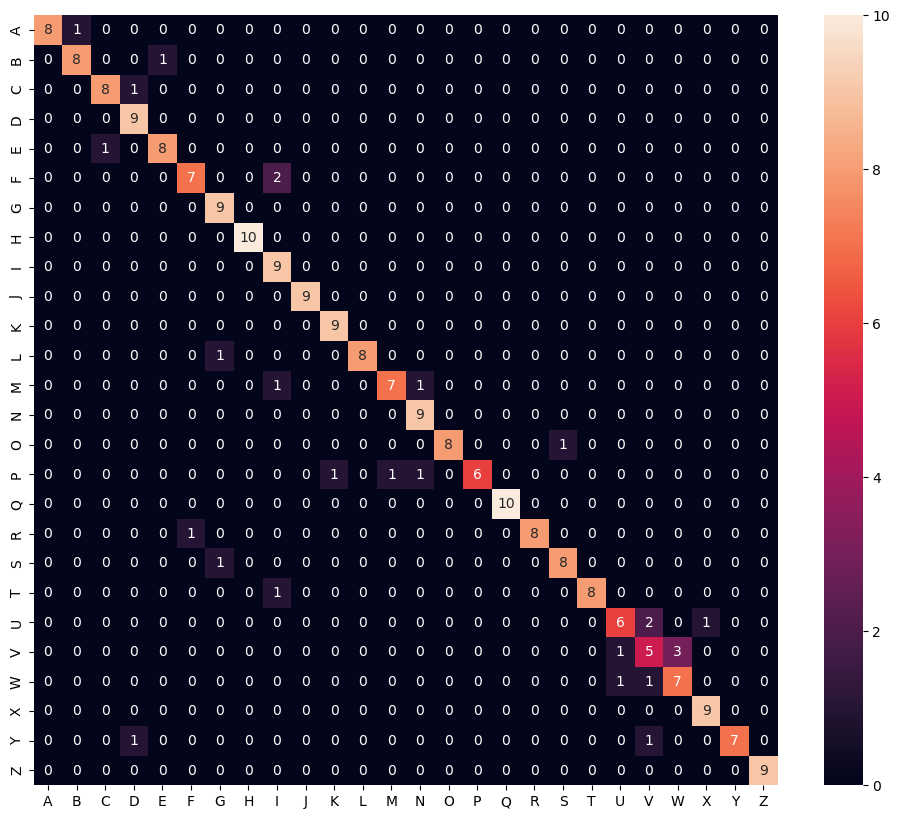

In [13]:
cm1 = confusion_matrix(y_test, preds2)

cm_df = pd.DataFrame(
    cm1,
    index=le.classes_,
    columns=le.classes_
)

plt.figure(figsize=(12,10))
sns.heatmap(cm_df, annot=True, fmt="d")
plt.show()

HYPERPARAMETER TRAINING AND K-FOLD TESTING

In [11]:
rf2 = RandomForestClassifier(
    random_state=42,
    n_estimators=1500,
    criterion="entropy",
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="log2",
    bootstrap=False,
    n_jobs=-1
)
selector = SelectFromModel(
    rf,
    threshold='median',
    prefit=True
)
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

rf2.fit(X_train_sel, y_train)

preds2 = rf2.predict(X_test_sel)

acc2 = accuracy_score(y_test, preds2)

print(f"Accuracy: {acc2:.4f}")

/home/satwik-biswas/Desktop/FlowKeys/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/home/satwik-biswas/Desktop/FlowKeys/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Accuracy: 0.8856


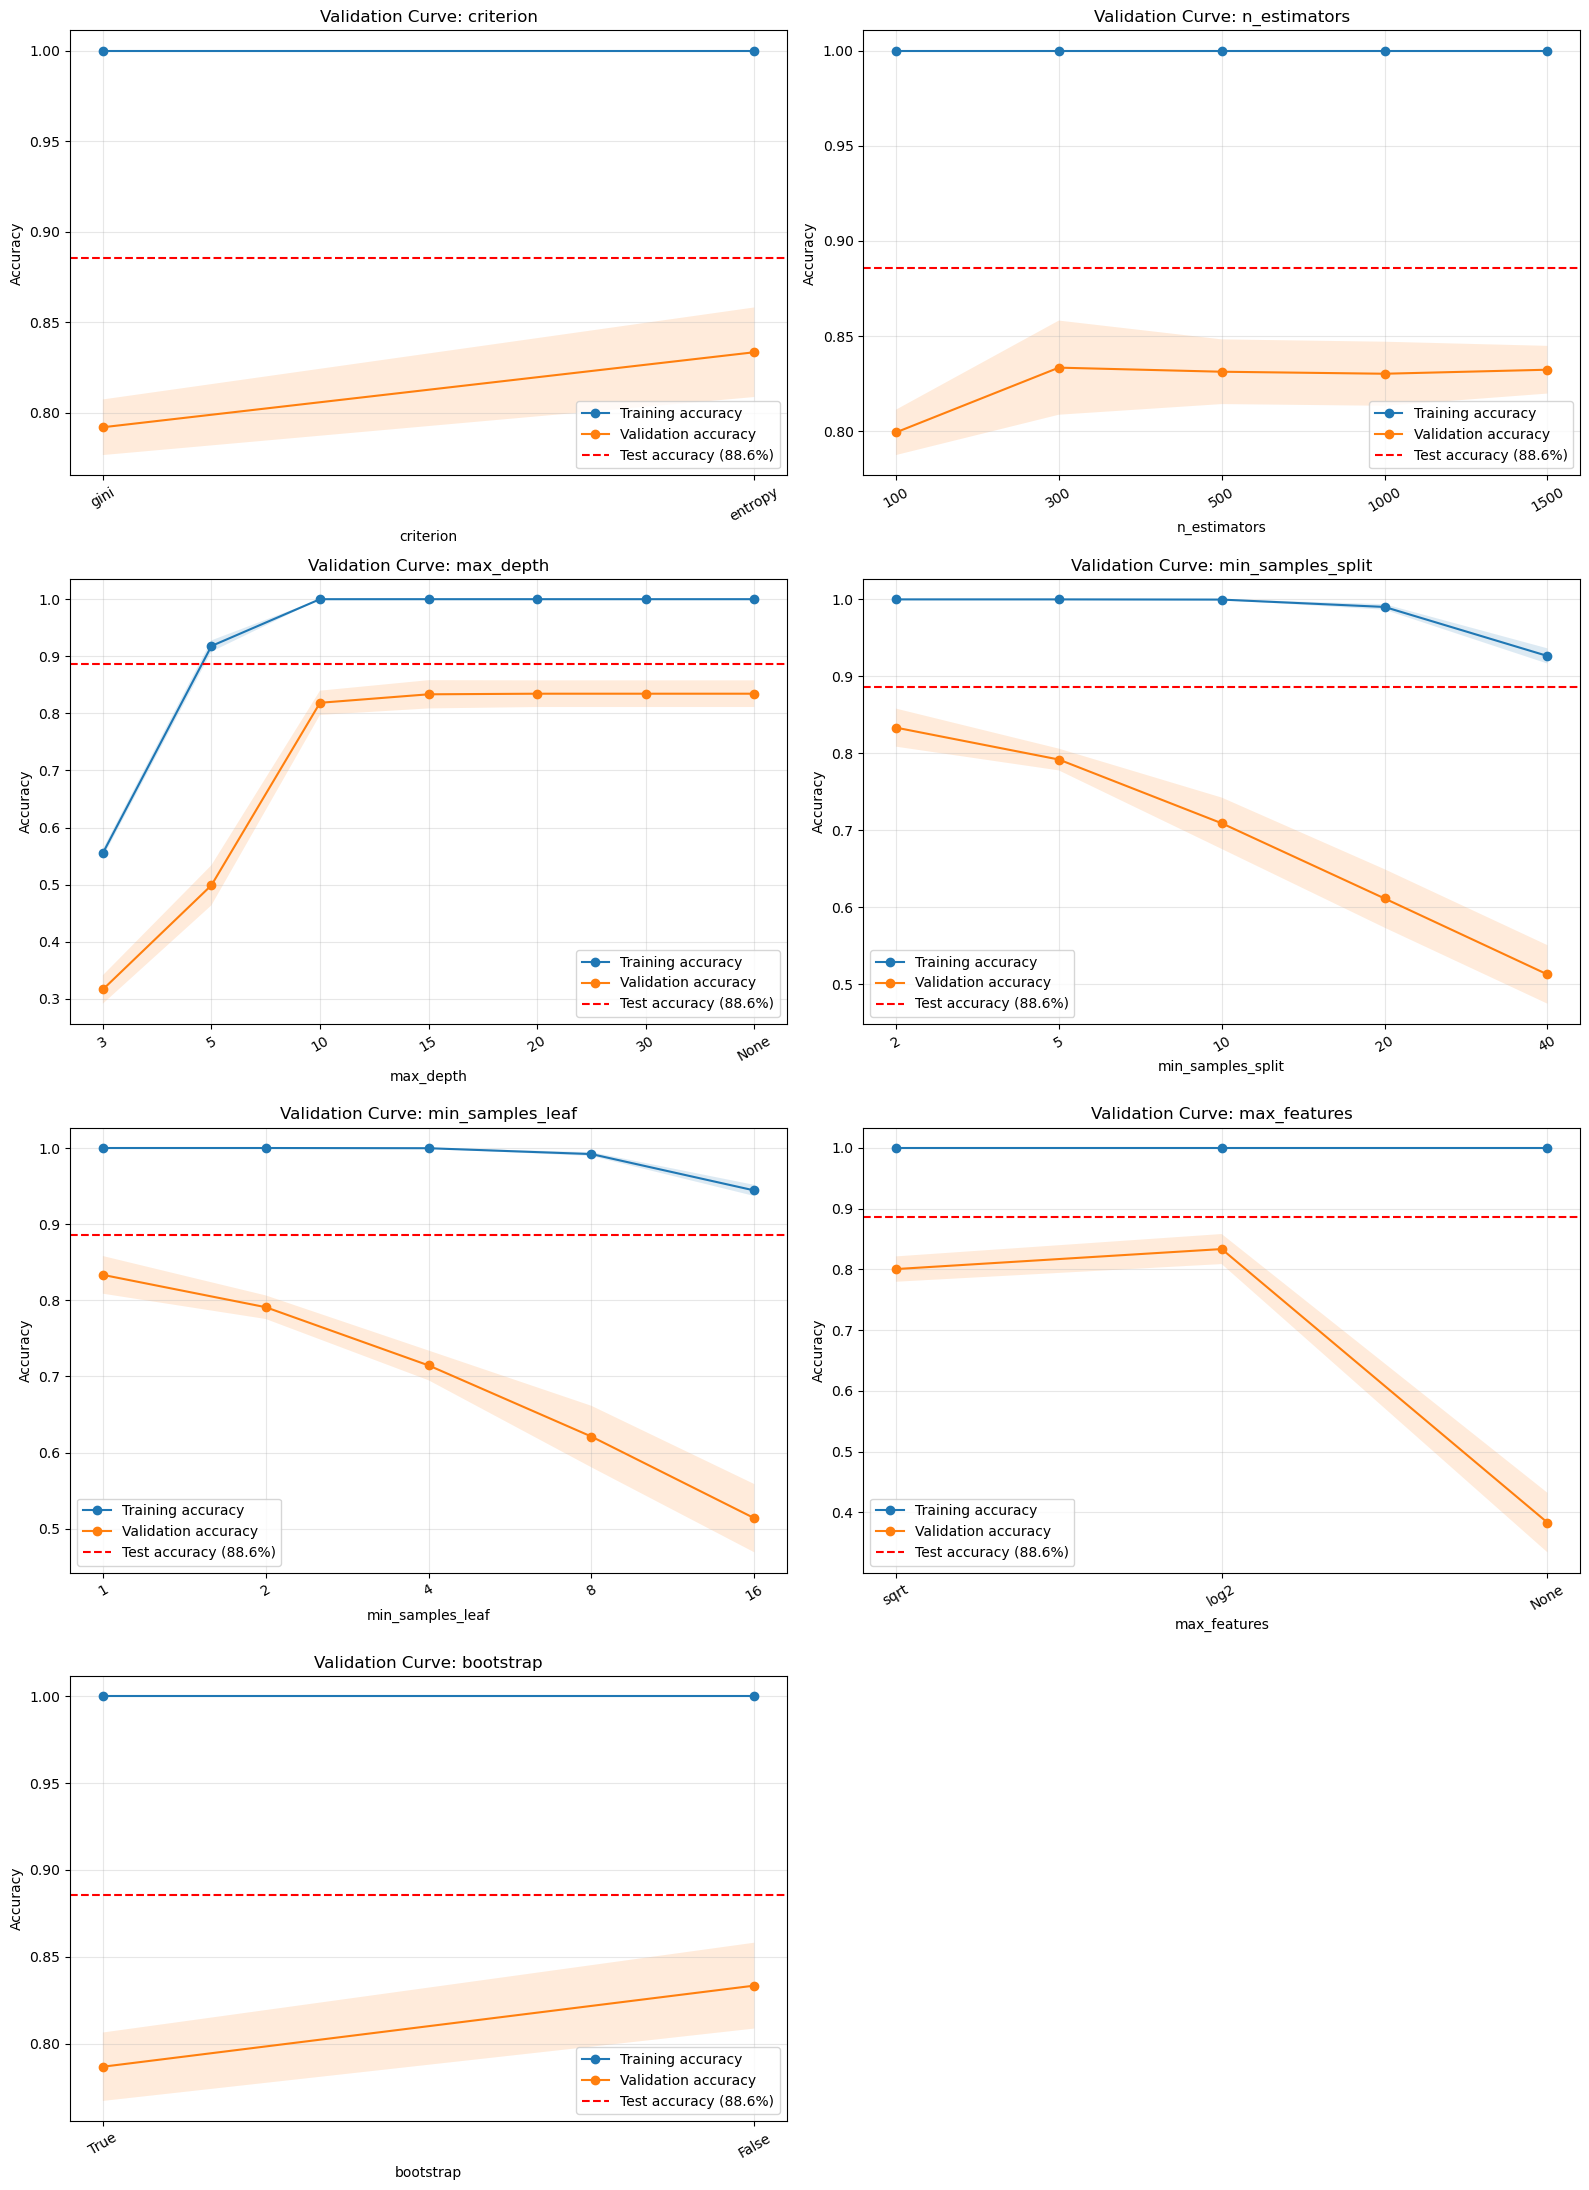

In [66]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import validation_curve, StratifiedKFold

# Values to test for each Random Forest hyperparameter
param_grid = {
    "criterion": ["gini", "entropy"],
    "n_estimators": [100, 300, 500, 1000, 1500],
    "max_depth": [3, 5, 10, 15, 20, 30, None],
    "min_samples_split": [2, 5, 10, 20, 40],
    "min_samples_leaf": [1, 2, 4, 8, 16],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

model_for_curves = clone(rf2)
model_for_curves.set_params(n_jobs=1,n_estimators=300)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Avoid nested parallel processing

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 22)
)

axes = axes.flatten()

results = {}

for ax, (param_name, param_values) in zip(axes, param_grid.items()):

    train_scores, val_scores = validation_curve(
        estimator=model_for_curves,
        X=X_train_sel,
        y=y_train,
        param_name=param_name,
        param_range=param_values,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    positions = np.arange(len(param_values))
    labels = [str(value) for value in param_values]

    ax.plot(
        positions,
        train_mean,
        marker="o",
        label="Training accuracy"
    )

    ax.plot(
        positions,
        val_mean,
        marker="o",
        label="Validation accuracy"
    )

    ax.fill_between(
        positions,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15
    )

    ax.fill_between(
        positions,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15
    )

    ax.axhline(
        acc2,
        color="red",
        linestyle="--",
        label=f"Test accuracy ({acc2:.1%})"
    )

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=30)
    ax.set_xlabel(param_name)
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Validation Curve: {param_name}")
    ax.grid(alpha=0.3)
    ax.legend()

    results[param_name] = {
        "values": param_values,
        "train_accuracy": train_mean,
        "validation_accuracy": val_mean,
        "gap": train_mean - val_mean
    }

# Remove unused subplot
for ax in axes[len(param_grid):]:
    ax.remove()

plt.tight_layout()
plt.show()

In [77]:
optimum_rf=RandomForestClassifier(
    criterion='entropy',         # Peak validation from your earlier curve
    n_estimators=1000,           # Higher trees give slight stability to validation
    max_depth=9,                # Where the CV line completely plateaus 
    max_features='log2',         # CRITICAL: Blocks feature noise (the peak on your graph)
    bootstrap=False,             # CRITICAL: Leverages 100% of your row data for accuracy spike
    min_samples_leaf=2,          # Kept at 1 to prevent validation drop
    min_samples_split=3,         # Kept at 2 to prevent validation drop
    random_state=42,
    n_jobs=-1
)
selector = SelectFromModel(
    rf,
    threshold='median',
    prefit=True
)
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

optimum_rf.fit(X_train_sel, y_train)

optimum_preds= optimum_rf.predict(X_test_sel)

optimum_acc = accuracy_score(y_test, optimum_preds)

print(f"Accuracy: {optimum_acc:.4f}")

/usr/lib/python3/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Accuracy: 0.8093


In [78]:
preds=optimum_rf.predict(X_train_sel)
acc=accuracy_score(y_train, preds)
print(acc)

1.0


In [73]:
optimum_rf1=RandomForestClassifier(
    criterion='entropy',         # Peak validation from your earlier curve
    n_estimators=1500,           # Higher trees give slight stability to validation
    max_depth=15,                # Where the CV line completely plateaus 
    max_features='log2',         # CRITICAL: Blocks feature noise (the peak on your graph)
    bootstrap=False,             # CRITICAL: Leverages 100% of your row data for accuracy spike
    min_samples_leaf=1,          # Kept at 1 to prevent validation drop
    min_samples_split=2,         # Kept at 2 to prevent validation drop
    random_state=42,
    n_jobs=-1
)

optimum_rf1.fit(X_train, y_train)

optimum_preds= optimum_rf1.predict(X_test)

optimum_acc = accuracy_score(y_test, optimum_preds)

print(f"Accuracy: {optimum_acc:.4f}")

Accuracy: 0.8771


In [17]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Update the grid based strictly on your visual curve results
param_distributions = {
    'n_estimators':[1000],       # High estimators keep the ensemble stable
    'criterion': ['entropy'],                 # Entropy peaked higher than Gini on your graph
    'max_depth':[15],            # Focus right around the plateau zone
    
    # CRITICAL FIXES BASED ON YOUR GRAPS:
    'bootstrap': [False],                     # Locked to False because it gave your 80% spike
    'max_features': ['log2'],                 # Locked to log2 to block your feature noise
    'min_samples_split':[2],              # Kept tight; higher values tanked your validation
    'min_samples_leaf': [1]                   # Locked to 1; higher values destroyed performance
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# rf2 should be initialized as your base RandomForestClassifier()
random_search = RandomizedSearchCV(
    estimator=rf2,
    param_distributions=param_distributions,
    n_iter=12,                                # Low iterations needed since space is clean
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42,
    scoring='accuracy',
    return_train_score=True                   # CRITICAL: Tracks training score to monitor overfitting
)

print("Starting Directed Randomized Search...")
random_search.fit(X_train_sel, y_train)
print("Search complete.")

# --- Evaluate results ---
print(f"\nBest parameters found: {random_search.best_params_}")

# Pull the training score associated with the best validation score
best_index = random_search.best_index_
best_train_score = random_search.cv_results_['mean_train_score'][best_index]

print(f"Best CV Training Accuracy: {best_train_score:.4f}")
print(f"Best CV Validation Accuracy: {random_search.best_score_:.4f}")

# Evaluate on test set
best_rf2_model = random_search.best_estimator_
best_preds = best_rf2_model.predict(X_test_sel)
best_acc = accuracy_score(y_test, best_preds)
print(f"Test accuracy with best parameters: {best_acc:.4f}")

Starting Directed Randomized Search...
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/lib/python3/dist-packages/sklearn/model_selection/_search.py:318: UserWarning: The total space of parameters 1 is smaller than n_iter=12. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END bootstrap=False, criterion=entropy, max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=1000; total time=   6.0s
[CV] END bootstrap=False, criterion=entropy, max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=1000; total time=   6.1s
[CV] END bootstrap=False, criterion=entropy, max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=1000; total time=   6.4s
[CV] END bootstrap=False, criterion=entropy, max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=1000; total time=   6.4s
[CV] END bootstrap=False, criterion=entropy, max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=1000; total time=   6.4s
Search complete.

Best parameters found: {'n_estimators': 1000, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15, 'criterion': 'entropy', 'bootstrap': False}
Best CV Training Ac

In [18]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score

# 1. Initialize the optimized model based on your validation curves
optimized_rf = RandomForestClassifier(
    n_estimators=1000,
    criterion='entropy',         # Peak from your criterion curve
    max_depth=15,                # Plateau point from your depth curve
    max_features='log2',         # CRITICAL: Blocks your feature noise
    bootstrap=False,             # CRITICAL: Gave you the 80% CV accuracy spike
    min_samples_leaf=1,          # Kept at 1 to prevent validation drop
    min_samples_split=2,         # Kept at 2 to prevent validation drop
    random_state=42,
    n_jobs=-1
)

# 2. Setup your existing 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Run cross-validation tracking both train and test scores
print("Running Stratified 5-Fold Cross-Validation...")
cv_results = cross_validate(
    estimator=optimized_rf,
    X=X_train_sel,
    y=y_train,
    cv=cv,
    scoring='accuracy',
    return_train_score=True,    # Allows you to verify the training baseline
    n_jobs=-1
)

# 4. Print the cross-validation results
mean_train_cv = np.mean(cv_results['train_score'])
mean_test_cv = np.mean(cv_results['test_score'])
print(f"Mean CV Training Accuracy: {mean_train_cv:.4f}")
print(f"Mean CV Validation Accuracy: {mean_test_cv:.4f}  <-- Your real-world performance")

# 5. Fit on the full training set and evaluate the final test set
print("\nEvaluating on final test set...")
optimized_rf.fit(X_train_sel, y_train)

test_preds = optimized_rf.predict(X_test_sel)
test_acc = accuracy_score(y_test, test_preds)
print(f"Final Test Accuracy: {test_acc:.4f}")

Running Stratified 5-Fold Cross-Validation...
Mean CV Training Accuracy: 1.0000
Mean CV Validation Accuracy: 0.8302  <-- Your real-world performance

Evaluating on final test set...
Final Test Accuracy: 0.8898


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_validate, StratifiedKFold,GridSearchCV
import numpy as np
from sklearn.feature_selection import VarianceThreshold

# 1. Define the base estimator for feature selection (your original rf baseline)
# Do NOT pre-fit this model manually anymore.
feature_selector_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# 2. Build a clean pipeline
# This guarantees feature selection happens INSIDE the K-fold loop safely.
model_pipeline = Pipeline([
    ('feature_selection', SelectFromModel(estimator=feature_selector_rf, threshold='median')),
    ('classification', optimized_rf),# Exploys your visually optimized parameters,
])

# 3. Use your 5-fold CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Run the Cross Validation on the RAW X_train data
print("Running Leakage-Free Pipeline Cross Validation...")
pipeline_cv_results = cross_validate(
    estimator=model_pipeline,
    X=X_train,                 # Use the RAW X_train (not X_train_sel!)
    y=y_train,
    cv=cv,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)

# 5. Review your new metrics
mean_train_pipe = np.mean(pipeline_cv_results['train_score'])
mean_val_pipe = np.mean(pipeline_cv_results['test_score'])

print(f"New Honest CV Training Accuracy: {mean_train_pipe:.4f}")
print(f"New Squeezed CV Validation Accuracy: {mean_val_pipe:.4f}")


Running Leakage-Free Pipeline Cross Validation...
New Honest CV Training Accuracy: 1.0000
New Squeezed CV Validation Accuracy: 0.7855


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split, GridSearchCV

# Define the seeds
seeds = [
    1,
    42,
    67,
    69,
    203,
    404,
    505,
    777,
    999,
    2025,
    3000,
    5000,
    6000,
    7000,
    8000,
    9000,
    10000,
]

# Define the parameter distributions to sample from for RandomizedSearch
param_distributions = {
    "n_estimators": [300, 500, 800, 1000, 1500],
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 20, 30, 40],
    "min_samples_split": [2, 3, 5, 8, 10],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_features": ["sqrt", "log2"],
}

# Lists to store accuracies for final statistics
rf1_accuracies = []
rf2_accuracies = []
rf2_tuned_accuracies = []
cv_scores = []

print("Running iterations over seeds...\n")
print(
    f"{'Seed':<8} | {'RF1 Accuracy':<14} | {'RF2 Accuracy':<14} | {'RF2 Tuned Acc':<14} | {'Best CV Score':<14}"
)
print("-" * 82)

for seed in seeds:
    # 1. Train/Test Split (Only changing this random_state)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )

    # 2. First Random Forest Model
    rf = RandomForestClassifier(
        random_state=42,
        n_estimators=1000,
        criterion="gini",
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        bootstrap=True,
        n_jobs=-1,
    )

    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    rf1_accuracies.append(acc)

    # 3. Feature Selection & Second Random Forest Model
    rf2 = RandomForestClassifier(
        random_state=42,
        n_estimators=1000,
        criterion="gini",
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        bootstrap=True,
        n_jobs=-1,
    )

    selector = SelectFromModel(rf, threshold="median", prefit=True)
    X_train_sel = selector.transform(X_train)
    X_test_sel = selector.transform(X_test)

    rf2.fit(X_train_sel, y_train)
    preds2 = rf2.predict(X_test_sel)
    acc2 = accuracy_score(y_test, preds2)
    rf2_accuracies.append(acc2)

    # 4. Hyperparameter Tuning on RF2 via RandomizedSearchCV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    random_search = RandomizedSearchCV(
        estimator=rf2,
        param_distributions=param_distributions,
        n_iter=100,
        cv=cv,
        n_jobs=-1,
        verbose=0,  # Turned verbose down to 0 to keep the loop table readable
        random_state=42,
        scoring="accuracy",
    )

    random_search.fit(X_train_sel, y_train)

    # Evaluate the best randomized search model on the test set
    best_rf2_model_random = random_search.best_estimator_
    best_preds_random = best_rf2_model_random.predict(X_test_sel)
    best_acc_random = accuracy_score(y_test, best_preds_random)
    rf2_tuned_accuracies.append(best_acc_random)
    best_cv_score = random_search.best_score_
    cv_scores.append(best_cv_score)

    # Print individual results for the current seed
    print(f"{seed:<8} | {acc:<14.4f} | {acc2:<14.4f} | {best_acc_random:<14.4f} | {best_cv_score:<14.4f}")

print("-" * 82)

# 5. Calculate and display Mean and Standard Deviation
print(
    f"\n{'Metric':<10} | {'RF1 Model':<14} | {'RF2 Model':<14} | {'RF2 Tuned':<14} | {'Best CV Score':<14}"
)
print("-" * 82)
print(
    f"{'Mean':<10} | {np.mean(rf1_accuracies):<14.4f} | {np.mean(rf2_accuracies):<14.4f} | {np.mean(rf2_tuned_accuracies):<14.4f} | {np.mean(cv_scores):<14.4f}"
)
print(
    f"{'Std Dev':<10} | {np.std(rf1_accuracies):<14.4f} | {np.std(rf2_accuracies):<14.4f} | {np.std(rf2_tuned_accuracies):<14.4f} | {np.std(cv_scores):<14.4f}"
)

Running iterations over seeds...

Seed     | RF1 Accuracy   | RF2 Accuracy   | RF2 Tuned Acc  | Best CV Score 
----------------------------------------------------------------------------------


c:\Users\Deydeepya\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
from scipy.stats import mode
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

def make_windows(df, L=30, stride=10):
    n = len(df)
    if n <= L: return [df]
    starts = list(range(0, n-L+1, stride))
    if starts[-1] != n-L: starts.append(n-L)
    return [df.iloc[s:s+L] for s in starts]

labels = np.array([r[1] for r in raw_recs])
le2 = LabelEncoder(); y_rec = le2.fit_transform(labels)
feat_cols = pd.DataFrame([extract_features(raw_recs[0][0], n_segments=2)]).columns

SEEDS = [0, 1, 7, 42, 123]
accs = []
for seed in SEEDS:
    tr, te = train_test_split(np.arange(len(raw_recs)), test_size=0.2, stratify=y_rec, random_state=seed)
    # train on all windows of train recordings
    Xtr, ytr = [], []
    for j in tr:
        for w in make_windows(raw_recs[j][0]):
            Xtr.append(extract_features(w, n_segments=2)); ytr.append(y_rec[j])
    Xtr = pd.DataFrame(Xtr).reindex(columns=feat_cols).fillna(0).values
    et = ExtraTreesClassifier(n_estimators=700, max_features='log2', n_jobs=-1, random_state=seed)
    et.fit(Xtr, np.array(ytr))
    # test: window -> predict -> majority vote per recording
    correct = 0
    for j in te:
        Xw = pd.DataFrame([extract_features(w, n_segments=2) for w in make_windows(raw_recs[j][0])])
        Xw = Xw.reindex(columns=feat_cols).fillna(0).values
        vote = mode(et.predict(Xw), keepdims=True).mode[0]
        correct += int(vote == y_rec[j])
    acc = correct/len(te); accs.append(acc); print(f'seed {seed}: {acc:.4f}')
print(f'\nWINDOW-AUG ExtraTrees + vote = {np.mean(accs):.4f} +/- {np.std(accs):.4f}')

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import numpy as np

classes = np.unique(y_train)

models = {}
selectors = {}

for cls in classes:

    print(f"Training model for {cls}")

    # One-vs-Rest labels
    y_binary = (y_train == cls).astype(int)

    # Initial RF
    rf = RandomForestClassifier(
        n_estimators=1500,
        criterion="entropy",
        max_depth=15,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="log2",
        bootstrap=False,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_binary)

    # Dynamic Feature Selection
    selector = SelectFromModel(
        rf,
        threshold="median",
        prefit=True
    )

    X_train_sel = selector.transform(X_train)

    # Final RF
    rf_final = RandomForestClassifier(
        n_estimators=1500,
        criterion="entropy",
        max_depth=15,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="log2",
        bootstrap=False,
        random_state=42,
        n_jobs=-1
    )

    rf_final.fit(X_train_sel, y_binary)

    models[cls] = rf_final
    selectors[cls] = selector

Training model for 0


/usr/lib/python3/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Training model for 1


/usr/lib/python3/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Training model for 2


...

/usr/lib/python3/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Training model for 24


/usr/lib/python3/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Training model for 25


/usr/lib/python3/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [84]:
predictions = []

for sample in X_test.to_numpy():

    probs = []

    sample = sample.reshape(1, -1)

    for cls in classes:

        selector = selectors[cls]
        model = models[cls]

        sample_sel = selector.transform(sample)

        prob = model.predict_proba(sample_sel)[0][1]

        probs.append(prob)

    predictions.append(classes[np.argmax(probs)])

predictions = np.array(predictions)

In [85]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, predictions)

print("Dynamic Feature Selection RF Accuracy:", acc)

Dynamic Feature Selection RF Accuracy: 0.788135593220339


In [86]:
predictions = []

for sample in X_train.to_numpy():

    probs = []

    sample = sample.reshape(1, -1)

    for cls in classes:

        selector = selectors[cls]
        model = models[cls]

        sample_sel = selector.transform(sample)

        prob = model.predict_proba(sample_sel)[0][1]

        probs.append(prob)

    predictions.append(classes[np.argmax(probs)])

predictions = np.array(predictions)

In [87]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_train, predictions)

print("Dynamic Feature Selection RF Accuracy:", acc)

Dynamic Feature Selection RF Accuracy: 1.0


In [12]:
from sklearn.ensemble import ExtraTreesClassifier
et_base=ExtraTreesClassifier(
    criterion="entropy",
    bootstrap=False,
    n_estimators=1500,
    n_jobs=-1,
    random_state=42,
    max_depth=15,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features="log2",
)

et_base.fit(X_train,y_train)
preds=et_base.predict(X_test)
acc=accuracy_score(y_test,preds)
print(acc)

0.8813559322033898


In [13]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': et_base.feature_importances_
})

importance_df = importance_df.sort_values(
    by='importance',

    ascending=False
)

print(importance_df.to_string(index=False))

                 feature  importance
     global_emg7_std_dev    0.005030
   segment2_emg7_std_dev    0.004261
segment3_accel_z_tot_eng    0.003934
     global_emg6_std_dev    0.003924
        segment2_yaw_max    0.003840
segment5_accel_z_tot_eng    0.003827
     global_emg1_std_dev    0.003791
    segment5_yaw_tot_eng    0.003776
    segment2_yaw_tot_eng    0.003776
      global_yaw_tot_eng    0.003773
        segment3_yaw_min    0.003753
        segment4_yaw_min    0.003752
        segment5_yaw_min    0.003750
    segment4_yaw_tot_eng    0.003734
       segment5_yaw_mean    0.003712
       segment4_yaw_mean    0.003711
          global_yaw_max    0.003704
        segment3_yaw_max    0.003702
    segment3_yaw_tot_eng    0.003697
   segment5_accel_z_mean    0.003688
        segment4_yaw_max    0.003671
   segment4_accel_z_mean    0.003659
        segment1_yaw_min    0.003641
    segment1_yaw_tot_eng    0.003614
segment4_accel_z_tot_eng    0.003605
   segment4_emg7_std_dev    0.003600
 

In [14]:
from sklearn.ensemble import ExtraTreesClassifier
et=ExtraTreesClassifier(
    criterion="entropy",
    bootstrap=False,
    n_estimators=1500,
    n_jobs=-1,
    random_state=42,
    max_depth=15,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features="log2",
)
selector_et = SelectFromModel(
    et_base,
    threshold='median',
    prefit=True
)
X_train_sel_et= selector_et.transform(X_train)
X_test_sel_et= selector_et.transform(X_test)

et.fit(X_train_sel_et,y_train)
preds=et.predict(X_test_sel_et)
acc=accuracy_score(y_test,preds)
print(acc)


c:\Users\Deydeepya\Desktop\github\SignLink\sign_lang_classification\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\Deydeepya\Desktop\github\SignLink\sign_lang_classification\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


0.902542372881356


In [ ]:
0.9152542372881356

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_validate, StratifiedKFold,GridSearchCV
import numpy as np
from sklearn.feature_selection import VarianceThreshold

# 1. Define the base estimator for feature selection (your original rf baseline)
# Do NOT pre-fit this model manually anymore.
feature_selector_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# 2. Build a clean pipeline
# This guarantees feature selection happens INSIDE the K-fold loop safely.
model_pipeline = Pipeline([
    ('feature_selection', SelectFromModel(estimator=et, threshold='median')),
    ('classification', et),# Exploys your visually optimized parameters,
])

# 3. Use your 5-fold CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Run the Cross Validation on the RAW X_train data
print("Running Leakage-Free Pipeline Cross Validation...")
pipeline_cv_results = cross_validate(
    estimator=model_pipeline,
    X=X_train,                 # Use the RAW X_train (not X_train_sel!)
    y=y_train,
    cv=cv,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)

# 5. Review your new metrics
mean_train_pipe = np.mean(pipeline_cv_results['train_score'])
mean_val_pipe = np.mean(pipeline_cv_results['test_score'])

print(f"New Honest CV Training Accuracy: {mean_train_pipe:.4f}")
print(f"New Squeezed CV Validation Accuracy: {mean_val_pipe:.4f}")


Running Leakage-Free Pipeline Cross Validation...
New Honest CV Training Accuracy: 1.0000
New Squeezed CV Validation Accuracy: 0.8535


In [ ]:
8535

In [18]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score

seeds = [
    1,
    42,
    67,
    69,
    203,
    404,
    505,
    777,
    999,
    2025,
    3000,
    5000,
    6000,
    7000,
    8000,
    9000,
    10000,
]

results = []

for seed in seeds:

    #############################################
    # RF -> ET
    #############################################

    rf_selector = RandomForestClassifier(
        random_state=seed,
        n_jobs=-1
    )

    et_classifier = ExtraTreesClassifier(
        criterion="entropy",
        bootstrap=False,
        n_estimators=1500,
        random_state=seed,
        max_depth=15,
        min_samples_leaf=1,
        min_samples_split=2,
        max_features="log2",
        n_jobs=-1
    )

    pipeline_rf = Pipeline([
        ('feature_selection',
         SelectFromModel(rf, threshold='median')),
        ('classifier', et_classifier)
    ])

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    cv_results = cross_validate(
        pipeline_rf,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    pipeline_rf.fit(X_train, y_train)
    rf_test_acc = accuracy_score(
        y_test,
        pipeline_rf.predict(X_test)
    )

    #############################################
    # ET -> ET
    #############################################

    et_selector = ExtraTreesClassifier(
        criterion="entropy",
        bootstrap=False,
        n_estimators=1500,
        random_state=seed,
        max_depth=15,
        min_samples_leaf=1,
        min_samples_split=2,
        max_features="log2",
        n_jobs=-1
    )

    pipeline_et = Pipeline([
        ('feature_selection',
         SelectFromModel(et_selector, threshold='median')),
        ('classifier', et_classifier)
    ])

    cv_results_et = cross_validate(
        pipeline_et,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    pipeline_et.fit(X_train, y_train)
    et_test_acc = accuracy_score(
        y_test,
        pipeline_et.predict(X_test)
    )

    #############################################

    results.append({
        "Seed": seed,

        "RF->ET CV": np.mean(cv_results['test_score']),
        "RF->ET Test": rf_test_acc,

        "ET->ET CV": np.mean(cv_results_et['test_score']),
        "ET->ET Test": et_test_acc
    })

results_df = pd.DataFrame(results)

print(results_df)

print("\n=============================")
print("Average Results")
print("=============================")

print(results_df.mean(numeric_only=True))

     Seed  RF->ET CV  RF->ET Test  ET->ET CV  ET->ET Test
0       1   0.858865     0.915254   0.869475     0.906780
1      42   0.843977     0.915254   0.853540     0.902542
2      67   0.875802     0.911017   0.870511     0.911017
3      69   0.847107     0.919492   0.836502     0.902542
4     203   0.871536     0.911017   0.874733     0.898305
5     404   0.863104     0.923729   0.868389     0.902542
6     505   0.863081     0.906780   0.865198     0.902542
7     777   0.858781     0.911017   0.868344     0.898305
8     999   0.859845     0.915254   0.864072     0.906780
9    2025   0.852465     0.915254   0.843938     0.902542
10   3000   0.882213     0.915254   0.879039     0.906780
11   5000   0.839733     0.915254   0.842913     0.902542
12   6000   0.878977     0.902542   0.880046     0.898305
13   7000   0.867325     0.898305   0.873708     0.902542
14   8000   0.852437     0.906780   0.863081     0.894068
15   9000   0.874721     0.911017   0.880029     0.894068
16  10000   0.

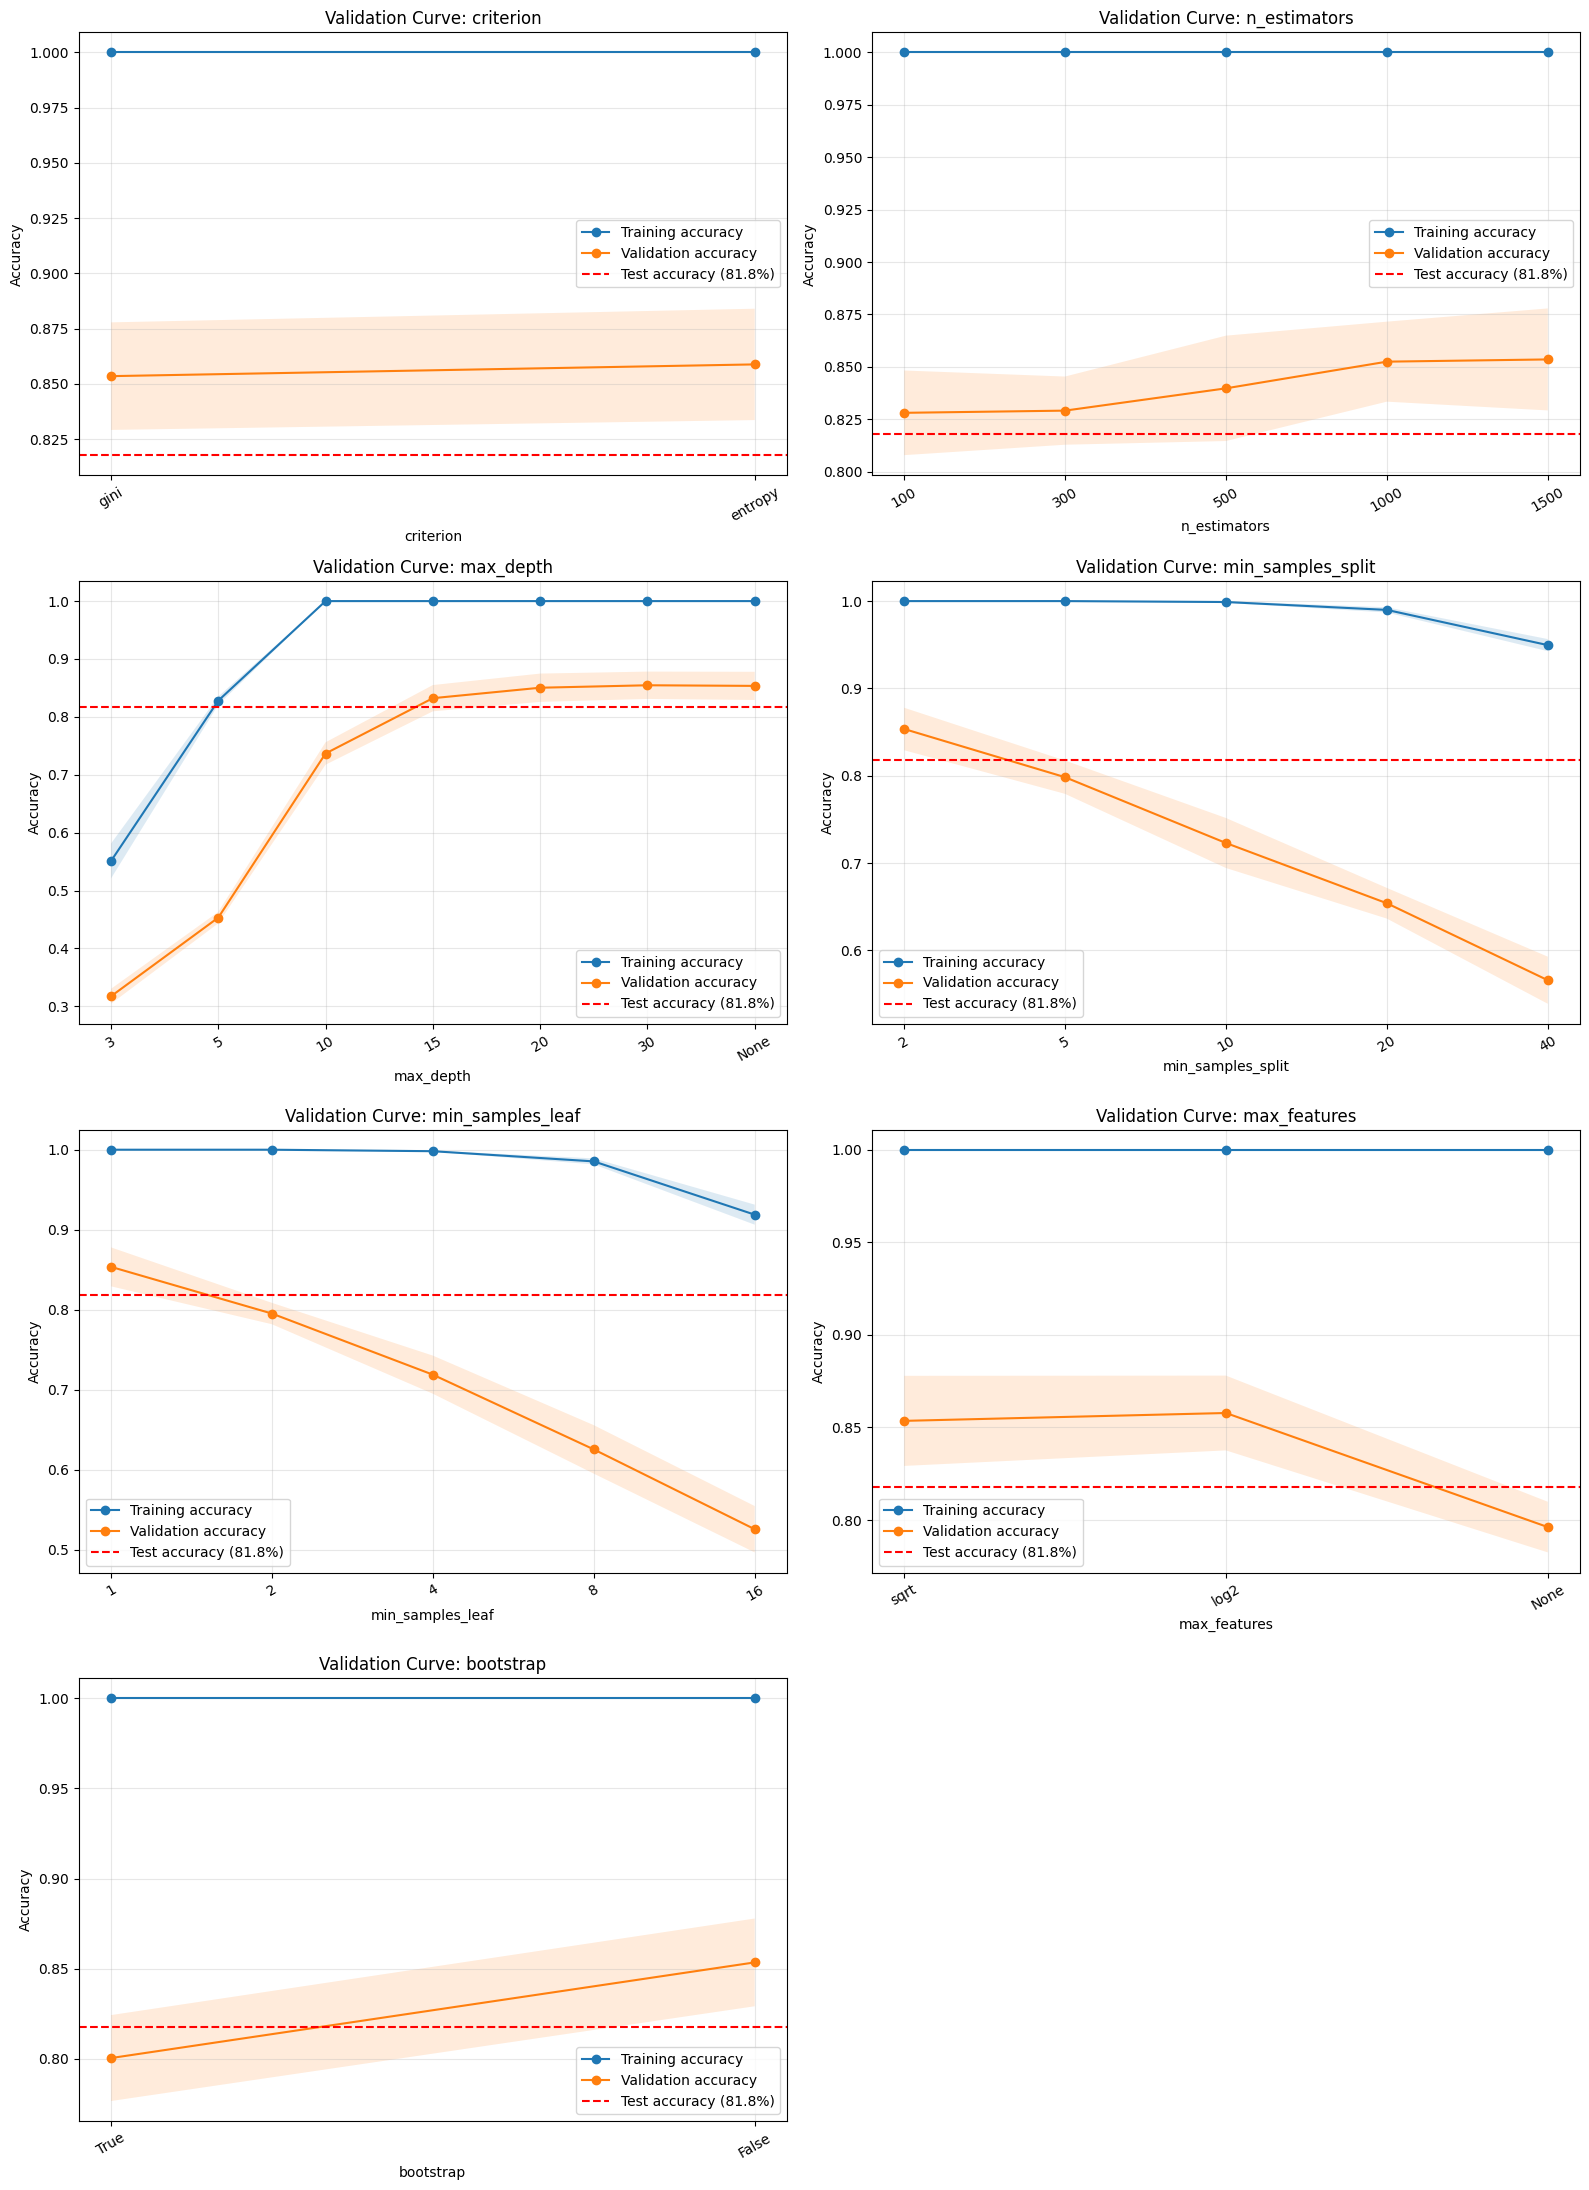

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import validation_curve, StratifiedKFold

# Values to test for each Extra Trees hyperparameter
param_grid = {
    "criterion": ["gini", "entropy"],
    "n_estimators": [100, 300, 500, 1000, 1500],
    "max_depth": [3, 5, 10, 15, 20, 30, None],
    "min_samples_split": [2, 5, 10, 20, 40],
    "min_samples_leaf": [1, 2, 4, 8, 16],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

model_for_curves = clone(et)
model_for_curves.set_params(n_jobs=1,n_estimators=1500)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Avoid nested parallel processing

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 22)
)

axes = axes.flatten()

results = {}

for ax, (param_name, param_values) in zip(axes, param_grid.items()):

    train_scores, val_scores = validation_curve(
        estimator=model_for_curves,
        X=X_train_sel,
        y=y_train,
        param_name=param_name,
        param_range=param_values,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    positions = np.arange(len(param_values))
    labels = [str(value) for value in param_values]

    ax.plot(
        positions,
        train_mean,
        marker="o",
        label="Training accuracy"
    )

    ax.plot(
        positions,
        val_mean,
        marker="o",
        label="Validation accuracy"
    )

    ax.fill_between(
        positions,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.15
    )

    ax.fill_between(
        positions,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.15
    )

    ax.axhline(
        acc2,
        color="red",
        linestyle="--",
        label=f"Test accuracy ({acc2:.1%})"
    )

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=30)
    ax.set_xlabel(param_name)
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Validation Curve: {param_name}")
    ax.grid(alpha=0.3)
    ax.legend()

    results[param_name] = {
        "values": param_values,
        "train_accuracy": train_mean,
        "validation_accuracy": val_mean,
        "gap": train_mean - val_mean
    }

# Remove unused subplot
for ax in axes[len(param_grid):]:
    ax.remove()

plt.tight_layout()
plt.show()

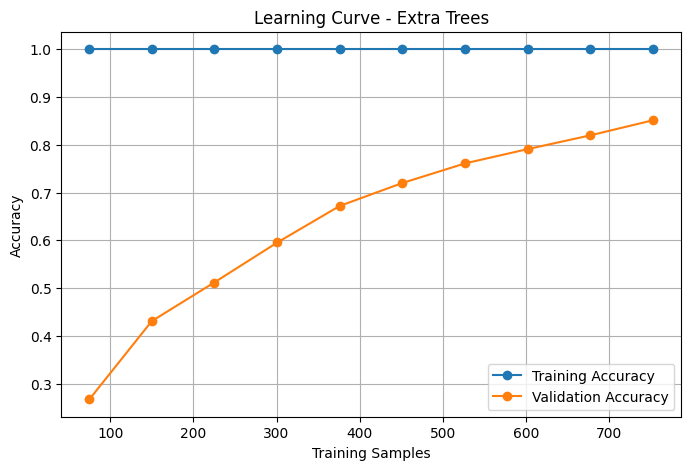

In [38]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

et=ExtraTreesClassifier(
    n_estimators=1500,
    n_jobs=-1,
    random_state=42,

)
train_sizes, train_scores, test_scores = learning_curve(
    et,
    X_train_sel,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, test_mean, marker='o', label='Validation Accuracy')

plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Extra Trees")
plt.legend()
plt.grid(True)
plt.show()

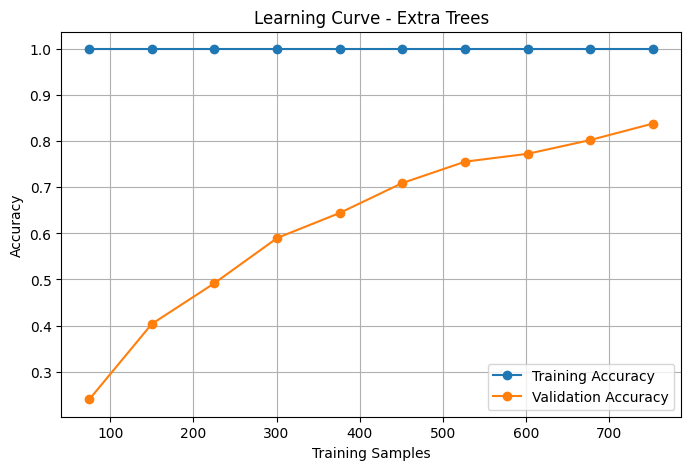

In [39]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

et=ExtraTreesClassifier(
    n_estimators=1500,
    n_jobs=-1,
    random_state=42,

)
train_sizes, train_scores, test_scores = learning_curve(
    rf2,
    X_train_sel,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, test_mean, marker='o', label='Validation Accuracy')

plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Extra Trees")
plt.legend()
plt.grid(True)
plt.show()

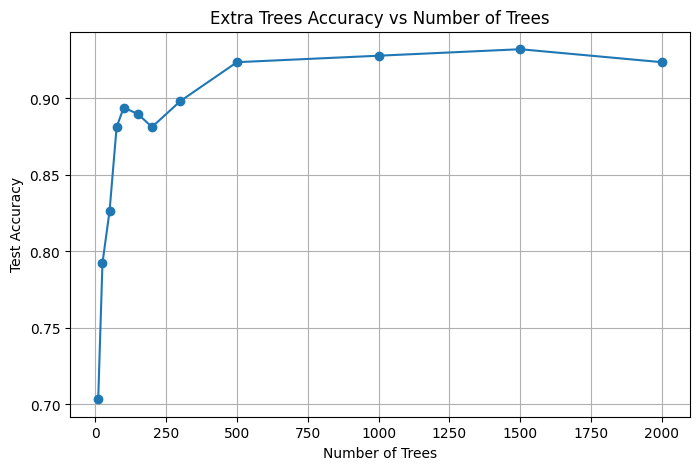

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score

trees = [10,25,50,75,100,150,200,300,500,1000,1500,2000]
acc = []

for n in trees:
    model=ExtraTreesClassifier(
    criterion="entropy",
    bootstrap=False,
    n_estimators=n,
    n_jobs=-1,
    random_state=42,
    max_depth=15,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features="log2",
)

    model.fit(X_train_sel, y_train)

    pred = model.predict(X_test_sel)

    acc.append(accuracy_score(y_test, pred))

plt.figure(figsize=(8,5))
plt.plot(trees, acc, marker='o')

plt.xlabel("Number of Trees")
plt.ylabel("Test Accuracy")
plt.title("Extra Trees Accuracy vs Number of Trees")
plt.grid(True)
plt.show()

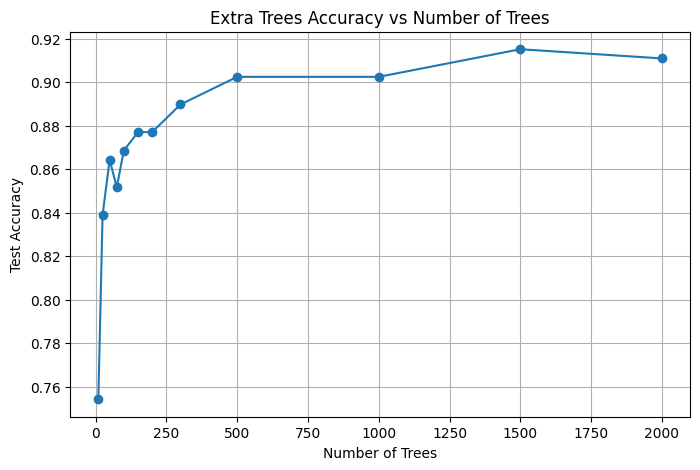

In [36]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score

trees = [10,25,50,75,100,150,200,300,500,1000,1500,2000]
acc = []

for n in trees:
    model=ExtraTreesClassifier(
    criterion="entropy",
    bootstrap=False,
    n_estimators=n,
    n_jobs=-1,
    random_state=42,
    max_depth=15,
    min_samples_leaf=1,
    min_samples_split=2,
    max_features="log2",
)

    model.fit(X_train_sel, y_train)

    pred = model.predict(X_test_sel)

    acc.append(accuracy_score(y_test, pred))

plt.figure(figsize=(8,5))
plt.plot(trees, acc, marker='o')

plt.xlabel("Number of Trees")
plt.ylabel("Test Accuracy")
plt.title("Extra Trees Accuracy vs Number of Trees")
plt.grid(True)
plt.show()